# Claims / payment-integrity ML — selective review capacity, joint certificates, and the calibration falsifier

**Notebook 3 of this three-part series.** This is a portfolio project, **not** a production system: every number
comes from a CPU-only synthetic claim stream with known latent truth (`claims_integrity`, package version 1.0.0),
never from real claims or PHI. This notebook **reuses notebook 2's stream verbatim** (seed 11, n = 1500, regime
`anchored`, digest asserted in Stage 1) and applies the three frozen papers to the same pipeline.

**Label legend used throughout:**

| Label | Meaning |
| --- | --- |
| `source-backed` | the mechanism or statement is tied to an equation, theorem or assumption in one of the three papers |
| `derived here` | the project's own synthetic construction or adaptation |
| `out of scope` | deliberately not claimed here |
| `preprint claim` | the SCoRC paper's benchmark numbers; none is quoted |

**The three branches compared at equal review capacity:**

| Branch | What it is | Validity condition | Status |
| --- | --- | --- | --- |
| SCRC-I | frozen scorer + **independent randomized-audit** calibration; one routing threshold chosen from a finite grid | exchangeable calibration (Theorem 2), fixed scorer/selector independent of calibration | `source-backed` mechanism, `derived here` collapse (binary auto-pay vs review) |
| SCoRC Algorithm 1 | disjoint train / tune / **cert** split, finite candidate grid, joint risk + acceptance + utility certificate, INFEASIBLE branch | i.i.d. cert data, selector fixed from train+tune only, finite grid, sample-size precondition | `source-backed` mechanism; its q10 **experiment numbers stay pending/preprint** |
| derived capacity baseline | naive vs noise-aware vs certificate-aware ranking under the same K budget: dollars recovered, precision-style dollars per review, provider burden | `derived here`; no population guarantee | `derived here` |

No SCoRC experiment number is quoted anywhere in this notebook.

**Palette** (one palette for the whole notebook): Okabe-Ito - `#0072B2` blue, `#D55E00` vermillion, `#009E73` green,
`#E69F00` orange, `#CC79A7` purple.

In [1]:
%matplotlib inline
import csv
import json
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

root = Path.cwd().resolve()
while not (root / "claims_integrity").is_dir():
    if root.parent == root:
        raise RuntimeError("could not locate the project root containing claims_integrity")
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import claims_integrity as ci

PALETTE = {
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "green": "#009E73",
    "orange": "#E69F00",
    "purple": "#CC79A7",
}

CHART_ARM_LABELS = {
    "randomized_audit": "randomized audit (exchangeable control)",
    "selected_high_risk": "scorer-selected high risk",
    "selected_low_risk": "scorer-selected low risk",
}


def pipe_table(headers, rows):
    lines = ["| " + " | ".join(str(h) for h in headers) + " |",
             "| " + " | ".join("---" for _ in headers) + " |"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    return "\n".join(lines)


def show(table):
    display(Markdown(table))


def f4(value):
    value = float(value)
    return "nan" if value != value else f"{value:.4f}"


def f3e(value):
    value = float(value)
    if value != value:
        return "nan"
    return f"{value:.3e}" if abs(value) >= 1e3 else f"{value:.4f}"


def finite_mean(values):
    values = [float(v) for v in values if v is not None and np.isfinite(float(v))]
    return float(np.mean(values)) if values else float("nan")


print("check 0: project root located")
print("check 0: package version:", ci.PACKAGE_VERSION, "| config hash:", ci.config_hash(ci.CONFIG)[:16], "...")
print("check 0: numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

check 0: project root located
check 0: package version: 1.0.0 | config hash: 0066ca74e7e74185 ...
check 0: numpy 2.0.2 | matplotlib 3.9.4


## Stage 1 - Data understanding

**Claim (CCEM, Ibrahim, Nguyen, Fu 2023).** Quoted from the paper:
*"Each annotator m is characterized by an individual column-stochastic confusion matrix A_m"* and, from the paper's
Eq. (6a-b), the CCEM *"negative log-likelihood with column-stochastic annotator matrices"*; Theorem 1 is stated
*"including the probability form and permutation ambiguity"*. So the stream must contain (a) a latent class per claim,
(b) several imperfect reviewers per claim, and (c) an unidentified class order that a deployed scorer must align.

**Claim (the selective family).** Quoted from the paper:

- (SCRC, Theorem 2 conditions): *"Calibration and test samples (X_i, Y_i) are exchangeable"*, and the guarantee
  *"E[l(C(X_{n+1}), Y_{n+1}) | g(X_{n+1}) >= 1 - lambda_1] <= alpha"*.
- (SCoRC Algorithm 1, step 1): *"Divide total failure probability budget delta equally into three parts: delta/3 for
  acceptance probability bounding, delta/3 for selected risk bounding, and delta/3 for deployment utility bounding"*, with
  the documented *"RETURN INFEASIBLE"* branch.
- (SCoRC Assumptions 6-7): *"Base classifier f, selection score g, candidate grid, and user parameters are constructed
  using only D_tr and D_tune"* and *"Constructing g directly from D_cert ... is strictly forbidden"*.
- (Assumption 5): *"n_cert >= 32 log(32m/delta) / pi_min"*.

**Out of scope here (labelled).** SCRC-T's transductive, symmetric two-stage prediction-set construction and its
set-size efficiency theorem are `out of scope`: the business decision modelled here is a binary auto-pay vs route-to-review
choice, so the implementation is a one-threshold collapse labelled `derived here`. The SCoRC paper's benchmark numbers are not quoted.

**Data understanding facts to verify below:** latent overpayment is rare, the dollar proxy is heavy-tailed, some claims are
genuinely ambiguous, all anchored-regime claims carry a reviewer verdict, and a 25% randomized-audit subsample exists
independently of any scorer.

In [2]:
# Stage 1 - regenerate the exact NB2 stream (seed 11) and prove verbatim reuse
STREAM_SEED = 11
N_CLAIMS = int(ci.CONFIG["n_claims"])
REGIME = "anchored"
stream = ci.make_claim_stream(seed=STREAM_SEED, n=N_CLAIMS, regime=REGIME)
digest = ci.stream_digest(stream)
expected_digest = "7b5d42b039401c3d29c06fe605427719b563171a1efb995a33ea38601ef65e2c"
assert digest == expected_digest, (digest, expected_digest)
print("check 1: NB2 stream digest reproduced:", digest[:32], "... == frozen NB2 digest")

y_latent = np.asarray(stream["y_latent"])
overpay_rate = float(stream["latent_overpayment"].mean())
ambiguous_share = float(stream["ambiguous"].mean())
audit_share = float(stream["audit_mask"].mean())
reviewed_share = float((np.asarray(stream["reviewer_id"]) >= 0).mean())
assert stream["n"] == N_CLAIMS and stream["regime"] == REGIME and stream["seed"] == STREAM_SEED
assert 0.0 < overpay_rate < 0.20 and 0.0 < ambiguous_share < 0.5
assert 0.15 <= audit_share <= 0.35 and reviewed_share > 0.95
print(f"check 2: stream identity: seed={stream['seed']} n={stream['n']} regime={stream['regime']} k={len(stream['class_names'])} classes={stream['class_names']}")
print(f"check 3: passive rates: overpayment={overpay_rate:.4f} ambiguous={ambiguous_share:.4f} audited={audit_share:.4f} reviewer-covered={reviewed_share:.4f}")
print(f"check 3: dollars: billed=${stream['billed'].sum():,.2f} recoverable=${stream['recoverable_dollars'].sum():,.2f} (heavy-tailed proxy, derived here)")

class_counts = np.bincount(y_latent, minlength=int(ci.CONFIG["k_latent"]))
stream_facts = [
    {"fact": "claims", "value": f"{N_CLAIMS}"},
    {"fact": "latent classes", "value": ", ".join(f"{n}={c}" for n, c in zip(stream["class_names"], class_counts))},
    {"fact": "latent overpayment rate", "value": f4(overpay_rate)},
    {"fact": "ambiguous share (true posterior, derived here)", "value": f4(ambiguous_share)},
    {"fact": "reviewed at least once (anchored regime)", "value": f4(reviewed_share)},
    {"fact": "randomized-audit subsample", "value": f"{int(stream['audit_mask'].sum())} claims ({audit_share:.4f})"},
    {"fact": "recoverable dollars (proxy)", "value": f"${stream['recoverable_dollars'].sum():,.2f}"},
    {"fact": "stream digest (first 32 hex)", "value": digest[:32]},
]
show("**Stream facts (all derived here; synthetic only).**\n\n" + pipe_table(["fact", "value"], [[r["fact"], r["value"]] for r in stream_facts]))

check 1: NB2 stream digest reproduced: 7b5d42b039401c3d29c06fe605427719 ... == frozen NB2 digest
check 2: stream identity: seed=11 n=1500 regime=anchored k=3 classes=('compliant', 'billing_error', 'medically_unnecessary')
check 3: passive rates: overpayment=0.0507 ambiguous=0.0780 audited=0.2393 reviewer-covered=1.0000
check 3: dollars: billed=$1,550,694.54 recoverable=$75,477.75 (heavy-tailed proxy, derived here)


**Stream facts (all derived here; synthetic only).**

| fact | value |
| --- | --- |
| claims | 1500 |
| latent classes | compliant=1424, billing_error=54, medically_unnecessary=22 |
| latent overpayment rate | 0.0507 |
| ambiguous share (true posterior, derived here) | 0.0780 |
| reviewed at least once (anchored regime) | 1.0000 |
| randomized-audit subsample | 359 claims (0.2393) |
| recoverable dollars (proxy) | $75,477.75 |
| stream digest (first 32 hex) | 7b5d42b039401c3d29c06fe605427719 |

## Stage 2 - Pre-processing

**Claim (Assumption 6).** Verbatim: *"The dataset is partitioned into disjoint i.i.d. splits
D_tr (union) D_tune (union) D_cert ~ P_XY"*. The three-way split below is exactly that protocol, and the certification
split is reserved for the certificate branch only.

**Claim (derived here).** Features are provider-level aggregates built **as of the claim's adjudication day** - only
strictly earlier claims of the same provider enter an aggregate - plus claim-level attributes and `log1p(billed)`. This is
the project's own no-peeking construction; the papers say nothing about feature engineering.

**Reuse table (verbatim NB2 calls, same function, same seed, same config).** The table below is produced by the same
`ci.build_features` / `ci.three_way_split` calls NB2 uses, under the same config hash, so NB2 and NB3 cannot drift.

In [3]:
# Stage 2 - rebuild features and splits with the same calls as NB2
features, feature_names = ci.build_features(stream)
split = ci.three_way_split(features.shape[0], STREAM_SEED)
train_idx, tune_idx, cert_idx = split["train"], split["tune"], split["cert"]
config_hash = ci.config_hash(ci.CONFIG)

sizes = {name: int(idx.size) for name, idx in split.items()}
assert sizes == {"train": 600, "tune": 300, "cert": 600}, sizes
assert np.intersect1d(train_idx, tune_idx).size == 0
assert np.intersect1d(train_idx, cert_idx).size == 0
assert np.intersect1d(tune_idx, cert_idx).size == 0
assert np.union1d(np.union1d(train_idx, tune_idx), cert_idx).size == N_CLAIMS
print(f"check 4: disjoint train/tune/cert splits: {sizes} (sum={sum(sizes.values())}); cert is disjoint from train and tune")

assert features.shape == (N_CLAIMS, int(ci.CONFIG["n_features"]) + 4), features.shape
assert len(feature_names) == features.shape[1]
print(f"check 5: feature matrix {features.shape} = {ci.CONFIG['n_features']} claim-level + 4 as-of provider aggregates")

leak = ci.no_leakage_probe(stream, probes=25, seed=7)
assert leak["ok"] is True
print(f"check 6: as-of feature probe: mutations of every strictly-later claim leave the probe rows bit-identical ({leak['checked']} probes, {leak['probes_with_future']} with later claims)")

assert len(config_hash) == 64 and all(c in "0123456789abcdef" for c in config_hash)
print("check 7: frozen config hash:", config_hash)

reuse_rows = [
    ["ci.make_claim_stream(seed=11, n=1500, regime='anchored')", "11", "digest asserted (check 1)", "1500 claims"],
    ["ci.build_features(stream)", "n/a (as-of, no RNG)", "config hash " + config_hash[:12] + "...", f"{features.shape[0]} x {features.shape[1]} features"],
    ["ci.three_way_split(n=1500, seed=11)", "11", "same seed as NB2", f"train={sizes['train']}, tune={sizes['tune']}, cert={sizes['cert']}"],
    ["ci.config_hash(ci.CONFIG)", "n/a", config_hash, "identity row for the run ledger"],
    ["ci.fit_scorers(stream, seed=11)", "11", "same call as NB2 (Stage 3)", "600/300/600 + naive + CCEM"],
]
show("**Reuse table (function, seed, config hash, split sizes, feature count).**\n\n" + pipe_table(
    ["function / call", "seed", "config hash / provenance", "shapes / sizes"], reuse_rows))

check 4: disjoint train/tune/cert splits: {'train': 600, 'tune': 300, 'cert': 600} (sum=1500); cert is disjoint from train and tune
check 5: feature matrix (1500, 14) = 10 claim-level + 4 as-of provider aggregates
check 6: as-of feature probe: mutations of every strictly-later claim leave the probe rows bit-identical (25 probes, 25 with later claims)
check 7: frozen config hash: 0066ca74e7e7418595d2a36e38d6004df7946fabb10c2e01ec79594132b9dbd2


**Reuse table (function, seed, config hash, split sizes, feature count).**

| function / call | seed | config hash / provenance | shapes / sizes |
| --- | --- | --- | --- |
| ci.make_claim_stream(seed=11, n=1500, regime='anchored') | 11 | digest asserted (check 1) | 1500 claims |
| ci.build_features(stream) | n/a (as-of, no RNG) | config hash 0066ca74e7e7... | 1500 x 14 features |
| ci.three_way_split(n=1500, seed=11) | 11 | same seed as NB2 | train=600, tune=300, cert=600 |
| ci.config_hash(ci.CONFIG) | n/a | 0066ca74e7e7418595d2a36e38d6004df7946fabb10c2e01ec79594132b9dbd2 | identity row for the run ledger |
| ci.fit_scorers(stream, seed=11) | 11 | same call as NB2 (Stage 3) | 600/300/600 + naive + CCEM |

## Stage 3 - Model training

**Claim.** CCEM fits reviewer confusion matrices and a softmax classifier jointly, and is
identified *"only up to a class permutation"*, so the clean class is recovered post hoc against the tune split's reviewer
verdicts (`derived here` Hungarian alignment). The branch (a) control uses SCRC-I with the paper's conditions - verbatim
*"Calibration and test samples (X_i, Y_i) are exchangeable"* (Theorem 2) - and the randomized audit is, by
construction, the one arm here that satisfies exchangeability. **This is the valid control arm.**

**Derived here / out of scope.** SCRC-T's symmetric transductive two-stage construction is `out of scope`; this notebook
uses the one-threshold inductive collapse (`ci.scrc_inductive_policy`) on a binary auto-pay/review action, and the
Eq. (15)-style counting quantile is applied to the accepted subset. The calibration loss is the **auditor verdict**
(verdict > 0), labelled `derived here`: that is a reviewer-noise-affected loss, not latent truth.

In [4]:
# Stage 3 - fit the frozen scorers ONCE (naive + noise-aware CCEM)
t_fit = time.perf_counter()
fit = ci.fit_scorers(stream, seed=STREAM_SEED)
fit_seconds = time.perf_counter() - t_fit
clean_class = int(fit["clean_class"])
class_mapping = [int(v) for v in fit["class_mapping"]]
assert sorted(class_mapping) == [0, 1, 2], class_mapping
assert fit["split"]["cert"].size == cert_idx.size and np.array_equal(fit["split"]["cert"], cert_idx)
posterior_train = ci.ccem_posterior(fit["ccem"], fit["features"])
assert np.allclose(posterior_train.sum(axis=1), 1.0)
print(f"check 8: clean class identified on the TUNE split: fitted class {clean_class}; Hungarian class mapping fitted->verdict = {class_mapping}")
print(f"check 8: fitted class names: " + ", ".join(f"{i}->{stream['class_names'][v]}" for i, v in enumerate(class_mapping)) + f" (latent names; mapping is {ci.CONFIG['k_latent']}-class permutation, Theorem 1)")
print(f"check 9: scorer posteriors are proper distributions (row sums = 1); naive model = {type(fit['naive']).__name__}; fit took {fit_seconds:.1f}s")

check 8: clean class identified on the TUNE split: fitted class 0; Hungarian class mapping fitted->verdict = [0, 1, 2]
check 8: fitted class names: 0->compliant, 1->billing_error, 2->medically_unnecessary (latent names; mapping is 3-class permutation, Theorem 1)
check 9: scorer posteriors are proper distributions (row sums = 1); naive model = LogisticRegression; fit took 0.2s


In [5]:
# Stage 3a - SCRC-I on the independent randomized-audit calibration subset
audit_idx = np.flatnonzero(stream["audit_mask"])
audit_raw = np.asarray(stream["audit_labels"])[audit_idx]
assert (audit_raw >= 0).all(), "audit items must carry a verdict"
audit_losses = np.where(audit_raw > 0, 1.0, 0.0)
clean_audit = 1.0 - ci.overpayment_score(fit["ccem"], fit["features"][audit_idx], clean_class=clean_class)
grid = tuple(round(float(x), 4) for x in np.linspace(0.0, 1.0, 101))
scrc = ci.scrc_inductive_policy(clean_audit, audit_losses, grid=grid, alpha=float(ci.CONFIG["alpha"]), xi=0.5)
again = ci.scrc_inductive_policy(clean_audit, audit_losses, grid=grid, alpha=float(ci.CONFIG["alpha"]), xi=0.5)
same = (scrc["feasible"] == again["feasible"] and scrc["threshold"] == again["threshold"]
        and scrc["accepted"] == again["accepted"] and np.array_equal(scrc["accept"], again["accept"]))
assert same
assert audit_losses.size == audit_idx.size and audit_losses.min() >= 0.0 and audit_losses.max() <= 1.0
print(f"check 10: SCRC-I is deterministic on repeat calls: feasible={scrc['feasible']} threshold={scrc['threshold']}")
print(f"check 11: bounded calibration loss verified: n={audit_losses.size} min={audit_losses.min():.1f} max={audit_losses.max():.1f}")

print("--- SCRC-I randomized-audit control (the valid, exchangeable calibration arm) ---")
print(f"  feasible : {scrc['feasible']}")
print(f"  threshold: {scrc['threshold']}")
print(f"  accepted : {scrc['accepted']} of {audit_losses.size}")
print(f"  risk     : {scrc['risk']}")
print(f"  coverage : {scrc['coverage']:.4f}")
print(f"  budget   : {scrc['budget']}  (Eq. (15) counting-quantile budget on the accepted subset)")
print(f"  reason   : {scrc['reason']}")
print(f"  audit verdict-based loss rate: {audit_losses.mean():.4f} (the auditor over-calls overpayment; latent rate is {overpay_rate:.4f})")

bracket = {}
for alpha in (0.05, 0.10, 0.15, 0.20, 0.25, 0.27, 0.30):
    policy = ci.scrc_inductive_policy(clean_audit, audit_losses, grid=grid, alpha=alpha, xi=0.5)
    bracket[alpha] = policy
    print(f"  [bracket] alpha={alpha:.2f} feasible={policy['feasible']} threshold={policy['threshold']} accepted={policy['accepted']} risk={policy['risk']}")
flags = [bracket[a]["feasible"] for a in sorted(bracket)]
assert all(not flags[i] or flags[i + 1] for i in range(len(flags) - 1)), "feasibility must be monotone in alpha"
print("check 12: SCRC-I feasibility is monotone non-decreasing in alpha over the probe bracket (the target must exceed the audit sample's own loss rate, ~0.27)")

check 10: SCRC-I is deterministic on repeat calls: feasible=False threshold=None
check 11: bounded calibration loss verified: n=359 min=0.0 max=1.0
--- SCRC-I randomized-audit control (the valid, exchangeable calibration arm) ---
  feasible : False
  threshold: None
  accepted : 0 of 359
  risk     : nan
  coverage : 0.0000
  budget   : 0  (Eq. (15) counting-quantile budget on the accepted subset)
  reason   : INFEASIBLE: no grid threshold meets the coverage floor and Eq. (15)
  audit verdict-based loss rate: 0.2730 (the auditor over-calls overpayment; latent rate is 0.0507)
  [bracket] alpha=0.05 feasible=False threshold=None accepted=0 risk=nan
  [bracket] alpha=0.10 feasible=False threshold=None accepted=0 risk=nan
  [bracket] alpha=0.15 feasible=False threshold=None accepted=0 risk=nan
  [bracket] alpha=0.20 feasible=False threshold=None accepted=0 risk=nan
  [bracket] alpha=0.25 feasible=False threshold=None accepted=0 risk=nan
  [bracket] alpha=0.27 feasible=True threshold=0.77 a

**Claim (SCoRC Algorithm 1).** Verbatim: the algorithm computes an *"Exact Clopper-Pearson LCB"* on
acceptance, an *"Empirical-Bernstein Variance-Adaptive Bound"* on selected risk, an empirical-Bernstein utility LCB, then a
*"Deterministic-Feasibility Filter"* that asks *"Is R_sel_UCB <= alpha AND p_acc_LCB >= pi_min AND n_cert >= n_star?"* and
returns either *"INFEASIBLE"* or the utility-maximising certified point. **Source-backed mechanism; `derived here` candidate
grid** (msp / margin families, thresholds fixed below).

**Claim (Assumptions 3, 5, 6, 7).** Verbatim: the grid is finite and data-independent (Assumption 3);
*"n_cert >= 32 log(32m/delta) / pi_min"* (Assumption 5); *"Base classifier f, selection score g, candidate grid, and user
parameters are constructed using only D_tr and D_tune"* (Assumption 6); and the selector is fixed conditional on
*(D_tr, D_tune)*, so nothing here is learned on the certification split (Assumption 7).

**Honesty note.** The candidate grid below is evaluated **only on the disjoint certification split**, with the model and
posterior frozen from the train/tune fit. The SCoRC paper's benchmark numbers are not quoted.

In [6]:
# Stage 3b - build the finite candidate grid on the disjoint CERT split and run the joint certificate
posterior = ci.ccem_posterior(fit["ccem"], features)
p_clean = posterior[:, clean_class]
other_max = np.delete(posterior, clean_class, axis=1).max(axis=1)
y_cert = np.asarray(stream["latent_overpayment"]).astype(float)[cert_idx]

msp_grid = (0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50)
margin_grid = (0.05, 0.10, 0.20, 0.30, 0.50, 0.70)
cert_value = float(ci.CONFIG["value_per_autopay"])
cert_cost_bound = 45.0  # declared, conservative per-review cost bound for the certificate utility

candidates = []
for threshold in msp_grid:
    candidates.append({
        "name": f"msp@{threshold:.3f}",
        "accept": p_clean[cert_idx] >= 1.0 - threshold,
        "loss": y_cert,
        "value": np.full(cert_idx.size, cert_value),
        "cost": np.full(cert_idx.size, cert_cost_bound),
    })
for threshold in margin_grid:
    candidates.append({
        "name": f"margin@{threshold:.3f}",
        "accept": (p_clean[cert_idx] - other_max[cert_idx]) >= threshold,
        "loss": y_cert,
        "value": np.full(cert_idx.size, cert_value),
        "cost": np.full(cert_idx.size, cert_cost_bound),
    })
assert len(candidates) == len(msp_grid) + len(margin_grid) == 13
assert all(cand["accept"].size == cert_idx.size for cand in candidates)
assert all(np.array_equal(cand["loss"], y_cert) for cand in candidates)
m = len(candidates)

strict = ci.scorec_certificate(
    candidates,
    alpha=float(ci.CONFIG["alpha"]),
    pi_min=float(ci.CONFIG["pi_min"]),
    delta=float(ci.CONFIG["delta"]),
    loss_bound=1.0,
    value_bound=cert_value,
    cost_bound=cert_cost_bound,
)
assert len(strict["ledger"]) == m
assert strict["n_cert"] == cert_idx.size == 600
assert strict["feasible"] is False and strict["chosen"] is None
for row in strict["ledger"]:
    assert np.isclose(row["delta_per_point"], float(ci.CONFIG["delta"]) / (3.0 * m)), row
assert strict["n_cert"] >= strict["n_star"]
print(f"check 13: candidate grid m={m} evaluated on the cert split only (n_cert={strict['n_cert']}); per-candidate failure budget delta/(3m)={strict['delta_per_point']:.6f}")
print(f"check 14: sample-size precondition satisfied: n_cert={strict['n_cert']} >= n_star={strict['n_star']:.2f} (Assumption 5) -> the refusal below is not a sample-size failure")
print(f"check 15: strict target alpha={strict['alpha']:.2f}: feasible={strict['feasible']} chosen={strict['chosen']} reason={strict['reason']}")
assert all(np.isfinite(row["risk_ucb"]) for row in strict["ledger"])
print(f"check 15: binding constraint check: risk_ucb > alpha for {sum(1 for r in strict['ledger'] if r['risk_ucb'] > strict['alpha'])}/{m} candidates; "
      f"acceptance_lcb < pi_min for {sum(1 for r in strict['ledger'] if r['acceptance_lcb'] < strict['pi_min'])}/{m}; "
      f"sample-size precondition holds for {sum(1 for r in strict['ledger'] if r['sample_size_ok'])}/{m}")

check 13: candidate grid m=13 evaluated on the cert split only (n_cert=600); per-candidate failure budget delta/(3m)=0.002564
check 14: sample-size precondition satisfied: n_cert=600 >= n_star=533.33 (Assumption 5) -> the refusal below is not a sample-size failure
check 15: strict target alpha=0.05: feasible=False chosen=None reason=INFEASIBLE: no certified grid point
check 15: binding constraint check: risk_ucb > alpha for 13/13 candidates; acceptance_lcb < pi_min for 4/13; sample-size precondition holds for 13/13


In [7]:
# Stage 3b (continued) - the looser sensitivity target, the certification boundary, and a guard on the frozen table
loose = ci.scorec_certificate(
    candidates,
    alpha=float(ci.CONFIG["alpha_sensitivity"]),
    pi_min=float(ci.CONFIG["pi_min"]),
    delta=float(ci.CONFIG["delta"]),
    loss_bound=1.0,
    value_bound=cert_value,
    cost_bound=cert_cost_bound,
)
print(f"check 16: sensitivity target alpha={float(ci.CONFIG['alpha_sensitivity']):.2f}: feasible={loose['feasible']} chosen={loose['chosen']} reason={loose['reason']}")

bracket = {}
for alpha in (0.05, 0.10, 0.11, 0.12, 0.15):
    result = ci.scorec_certificate(candidates, alpha=alpha, pi_min=float(ci.CONFIG["pi_min"]),
                                   delta=float(ci.CONFIG["delta"]), loss_bound=1.0,
                                   value_bound=cert_value, cost_bound=cert_cost_bound)
    bracket[alpha] = result
    chosen = None if not result["feasible"] else result["chosen"]["name"]
    print(f"  [bracket] alpha={alpha:.2f} feasible={result['feasible']} chosen={chosen}")
assert bracket[0.05]["feasible"] is False and bracket[0.10]["feasible"] is False
first_feasible = min(a for a, r in bracket.items() if r["feasible"])
assert first_feasible == 0.11, first_feasible
assert bracket[0.11]["chosen"]["name"] == "msp@0.300"
assert np.isclose(bracket[0.11]["chosen"]["risk_ucb"], 0.1056, atol=5e-4)
print(f"check 17: certification boundary probed: first feasible target in the bracket is alpha={first_feasible:.2f} (chosen {bracket[0.11]['chosen']['name']}, risk_ucb={bracket[0.11]['chosen']['risk_ucb']:.4f})")

# drift guard: the live ledger must reproduce the frozen Markdown table of the next cell
frozen_ledger = json.loads(r'''[{"name": "msp@0.010", "accept_count": 0, "routed_on_cert": 600, "acceptance_lcb": 0.0, "risk_ucb": 23240415789.62476, "utility_lcb": -46.266603, "empirical_utility": -45.0, "empirical_risk": NaN, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.02324, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "msp@0.020", "accept_count": 0, "routed_on_cert": 600, "acceptance_lcb": 0.0, "risk_ucb": 23240415789.62476, "utility_lcb": -46.266603, "empirical_utility": -45.0, "empirical_risk": NaN, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.02324, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "msp@0.050", "accept_count": 0, "routed_on_cert": 600, "acceptance_lcb": 0.0, "risk_ucb": 23240415789.62476, "utility_lcb": -46.266603, "empirical_utility": -45.0, "empirical_risk": NaN, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.02324, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "msp@0.100", "accept_count": 66, "routed_on_cert": 534, "acceptance_lcb": 0.077161, "risk_ucb": 0.378259, "utility_lcb": -42.678383, "empirical_utility": -39.005, "empirical_risk": 0.015152, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.029162, "slack_utility": 3.673383, "sample_size_ok": true}, {"name": "msp@0.200", "accept_count": 431, "routed_on_cert": 169, "acceptance_lcb": 0.66422, "risk_ucb": 0.118986, "utility_lcb": -10.577434, "empirical_utility": -5.850833, "empirical_risk": 0.046404, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.048405, "slack_utility": 4.7266, "sample_size_ok": true}, {"name": "msp@0.300", "accept_count": 578, "routed_on_cert": 22, "acceptance_lcb": 0.936392, "risk_ucb": 0.107292, "utility_lcb": 4.789394, "empirical_utility": 7.501667, "empirical_risk": 0.050173, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.053481, "slack_utility": 2.712272, "sample_size_ok": true}, {"name": "msp@0.500", "accept_count": 600, "routed_on_cert": 0, "acceptance_lcb": 0.990106, "risk_ucb": 0.113164, "utility_lcb": 8.233397, "empirical_utility": 9.5, "empirical_risk": 0.056667, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.055873, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "margin@0.050", "accept_count": 600, "routed_on_cert": 0, "acceptance_lcb": 0.990106, "risk_ucb": 0.113164, "utility_lcb": 8.233397, "empirical_utility": 9.5, "empirical_risk": 0.056667, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.055873, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "margin@0.100", "accept_count": 600, "routed_on_cert": 0, "acceptance_lcb": 0.990106, "risk_ucb": 0.113164, "utility_lcb": 8.233397, "empirical_utility": 9.5, "empirical_risk": 0.056667, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.055873, "slack_utility": 1.266603, "sample_size_ok": true}, {"name": "margin@0.200", "accept_count": 598, "routed_on_cert": 2, "acceptance_lcb": 0.98329, "risk_ucb": 0.111611, "utility_lcb": 7.608368, "empirical_utility": 9.318333, "empirical_risk": 0.055184, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.055414, "slack_utility": 1.709966, "sample_size_ok": true}, {"name": "margin@0.300", "accept_count": 594, "routed_on_cert": 6, "acceptance_lcb": 0.972455, "risk_ucb": 0.112633, "utility_lcb": 6.923043, "empirical_utility": 8.955, "empirical_risk": 0.055556, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.055408, "slack_utility": 2.031957, "sample_size_ok": true}, {"name": "margin@0.500", "accept_count": 573, "routed_on_cert": 27, "acceptance_lcb": 0.925982, "risk_ucb": 0.108379, "utility_lcb": 4.186293, "empirical_utility": 7.0475, "empirical_risk": 0.050611, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.053474, "slack_utility": 2.861207, "sample_size_ok": true}, {"name": "margin@0.700", "accept_count": 368, "routed_on_cert": 232, "acceptance_lcb": 0.555995, "risk_ucb": 0.13348, "utility_lcb": -16.585884, "empirical_utility": -11.573333, "empirical_risk": 0.048913, "feasible": false, "delta_per_point": 0.002564, "slack_risk": 0.047081, "slack_utility": 5.01255, "sample_size_ok": true}]''')
live_ledger = strict["ledger"]
assert len(live_ledger) == len(frozen_ledger)
for live_row, frozen_row in zip(live_ledger, frozen_ledger):
    assert live_row["name"] == frozen_row["name"]
    assert live_row["accept_count"] == frozen_row["accept_count"]
    assert bool(live_row["feasible"]) == bool(frozen_row["feasible"])
    for key in ("acceptance_lcb", "risk_ucb", "utility_lcb"):
        assert np.isclose(live_row[key], frozen_row[key], rtol=1e-3, atol=5e-5), (live_row["name"], key, live_row[key], frozen_row[key])
    if np.isfinite(frozen_row["empirical_risk"]):
        assert np.isclose(live_row["empirical_risk"], frozen_row["empirical_risk"], rtol=1e-3, atol=5e-5)
    else:
        assert not np.isfinite(live_row["empirical_risk"])
print("check 18: live certificate ledger reproduces the frozen Markdown ledger table (names, counts, flags, and all bounds within tolerance)")

check 16: sensitivity target alpha=0.10: feasible=False chosen=None reason=INFEASIBLE: no certified grid point
  [bracket] alpha=0.05 feasible=False chosen=None
  [bracket] alpha=0.10 feasible=False chosen=None
  [bracket] alpha=0.11 feasible=True chosen=msp@0.300
  [bracket] alpha=0.12 feasible=True chosen=msp@0.500
  [bracket] alpha=0.15 feasible=True chosen=msp@0.500
check 17: certification boundary probed: first feasible target in the bracket is alpha=0.11 (chosen msp@0.300, risk_ucb=0.1056)
check 18: live certificate ledger reproduces the frozen Markdown ledger table (names, counts, flags, and all bounds within tolerance)


**The full certificate ledger (SCoRC Algorithm 1, strict target alpha = 0.05, delta = 0.10, pi_min = 0.50,
m = 13, n_cert = 600).** This table is the frozen ledger: the code cell above recomputes it live and asserts every row
reproduces it within tolerance. `delta/(3m)` = 0.002564 is the per-candidate failure budget, and
`n_star` = 533.33 (Assumption 5) is satisfied at n_cert = 600.

| candidate | accepted (n=600) | acceptance LCB | risk UCB | utility LCB | empirical risk | feasible |
| --- | --- | --- | --- | --- | --- | --- |
| msp@0.010 | 0 | 0.0000 | 2.324e+10 | -46.2666 | n/a (0 accepted) | no |
| msp@0.020 | 0 | 0.0000 | 2.324e+10 | -46.2666 | n/a (0 accepted) | no |
| msp@0.050 | 0 | 0.0000 | 2.324e+10 | -46.2666 | n/a (0 accepted) | no |
| msp@0.100 | 66 | 0.0772 | 0.3783 | -42.6784 | 0.0152 | no |
| msp@0.200 | 431 | 0.6642 | 0.1190 | -10.5774 | 0.0464 | no |
| msp@0.300 | 578 | 0.9364 | 0.1073 | 4.7894 | 0.0502 | no |
| msp@0.500 | 600 | 0.9901 | 0.1132 | 8.2334 | 0.0567 | no |
| margin@0.050 | 600 | 0.9901 | 0.1132 | 8.2334 | 0.0567 | no |
| margin@0.100 | 600 | 0.9901 | 0.1132 | 8.2334 | 0.0567 | no |
| margin@0.200 | 598 | 0.9833 | 0.1116 | 7.6084 | 0.0552 | no |
| margin@0.300 | 594 | 0.9725 | 0.1126 | 6.9230 | 0.0556 | no |
| margin@0.500 | 573 | 0.9260 | 0.1084 | 4.1863 | 0.0506 | no |
| margin@0.700 | 368 | 0.5560 | 0.1335 | -16.5859 | 0.0489 | no |

**Binding constraint at the strict target.** The certificate refuses because **risk UCB > alpha on every candidate** - the
empirical-Bernstein slack at n_cert = 600, m = 13, delta = 0.10 is about 0.056, so no candidate can exhibit a risk UCB at
or below 0.05. Acceptance is *not* the binding constraint for the candidates that accept anything: their acceptance LCBs
sit far above the 0.50 floor (the three `msp` candidates at thresholds 0.01/0.02/0.05 accept **zero** claims and fail the
floor instead, with a degenerate risk UCB from the 1e-12 denominator floor). The sample-size precondition is satisfied
everywhere, so the refusal is a genuine power/attainability statement, not a sample-size failure.

**What the looser target does.** One might expect the configured sensitivity
target alpha = 0.10 to certify. With the current package it does **not**: the same empirical-Bernstein slack binds and 0.10 is
still infeasible (the code cell above asserts this). The probed certification boundary is **alpha = 0.11**, where the first
certified point appears (`msp@0.300` with acceptance LCB 0.9364, risk UCB
0.1056, utility LCB 4.7894); the boundary probe and its numbers are `derived here`
(an exploratory bracket, not a paper result). The SCoRC paper's benchmark numbers are not quoted.

**Cost declaration.** The certificate's utility uses the declared per-review cost bound $45.00 - deliberately conservative
relative to the $4.50/review implied by the config's minutes x cost-per-minute accounting used in the capacity/dollar
branch. It affects only the utility LCB, not the risk/acceptance feasibility.

**Claim (score functions and grids).** Verbatim: *"The selection function g: X -> [1] quantifies
model confidence to decide whether a claim is accepted for automated processing or rejected (abstained)"*, and the four
paper score families are MSP, *"Margin: p_(1) - p_(2) (difference between the top two class probabilities; used as default
choice in benchmark plots)"*, entropy and energy. This branch keeps MSP/margin and sweeps a finite grid.

**Derived here.** Two facts are stated and then verified rather than assumed:

1. at equal review capacity the **noise-aware (CCEM) ranking has lower accepted risk than the naive (single-verdict)
   ranking at every capacity and seed** - the gap is small because reviewing K <= 80 of 1500 claims leaves 95-99% of
   claims on auto-pay; and
2. the **selective (certificate) arm is INFEASIBLE at all three capacities** (the same alpha = 0.05 target and the same
   finite-sample slack as Stage 3b). Those points are **marked, not dropped**: the infeasible selective rows fall back to
   accept-everything and are displayed with their feasibility flag.

The dollar context is a `derived here` synthetic proxy: recoverable dollars are heavy-tailed, and run costs are
minutes x cost-per-minute from `ci.CONFIG`. Precision-style context below is dollars per reviewed claim (a precision
proxy, not a calibrated precision).

In [8]:
# Stage 3c - derived capacity baseline at equal K, plus the dollar context (per-seed timings feed the run ledger)
capacity_rows = []
ledger_records = []
for seed in (11, 23):
    t_seed = time.perf_counter()
    rows = ci.capacity_study(seeds=(seed,), n=N_CLAIMS, capacities=(20, 40, 80))
    elapsed = time.perf_counter() - t_seed
    capacity_rows.extend(rows)
    for capacity in (20, 40, 80):
        ledger_records.append(ci.record_run(seed=seed, config=ci.CONFIG, capacity=int(capacity), runtime_seconds=elapsed))

t_dollars = time.perf_counter()
dollars_rows = ci.dollars_study(seeds=(11, 23))
dollars_seconds = time.perf_counter() - t_dollars

assert len(capacity_rows) == 18 and len(dollars_rows) == 12
assert {r["policy"] for r in capacity_rows} == {"naive", "noise-aware", "selective"}
naive = {(r["seed"], r["capacity_claims"]): r["risk"] for r in capacity_rows if r["policy"] == "naive"}
aware = {(r["seed"], r["capacity_claims"]): r["risk"] for r in capacity_rows if r["policy"] == "noise-aware"}
pairs = sorted(naive)
assert all(aware[k] < naive[k] for k in pairs)
print(f"check 19: noise-aware accepted risk < naive accepted risk at every capacity and seed ({len(pairs)}/{len(pairs)} pairs)")
selective = [r for r in capacity_rows if r["policy"] == "selective"]
assert len(selective) == 6 and all(r["feasible"] is False for r in selective)
assert all(np.isclose(r["acceptance"], 1.0) for r in selective)
print("check 20: selective (certificate) rows are present and marked INFEASIBLE at all 6 (capacity, seed) points (accept-everything fallback shown, never dropped)")
for r in dollars_rows:
    assert np.isclose(r["net_utility"], r["dollars_recovered"] - r["review_cost"], rtol=1e-9)
    assert np.isclose(r["review_cost"], r["reviewed_minutes"] * float(ci.CONFIG["cost_per_minute"]), rtol=1e-9)
    assert r["claims_reviewed"] == max(1, int(round(r["reviewed_minutes"] / float(ci.CONFIG["minutes_per_review"]))))
print(f"check 21: dollar rows use the config accounting: review_cost = minutes x ${float(ci.CONFIG['cost_per_minute']):.2f}/min and net_utility = recovered - review_cost (all 12 rows)")
assert all(rec["config_hash"] == config_hash for rec in ledger_records) and len(ledger_records) == 6
assert all(rec["runtime_seconds"] > 0 for rec in ledger_records)
print(f"check 22: run ledger: {len(ledger_records)} records, every config hash equals the frozen hash, every runtime > 0 (dollars study took {dollars_seconds:.1f}s)")

by_cap_policy = {}
for row in capacity_rows:
    by_cap_policy.setdefault((row["policy"], row["capacity_claims"]), []).append(row)
capacity_table = []
for policy in ("naive", "noise-aware", "selective"):
    for capacity in (20, 40, 80):
        group = by_cap_policy[(policy, capacity)]
        capacity_table.append([
            policy,
            capacity,
            f"{capacity * float(ci.CONFIG['minutes_per_review']):.0f}",
            f4(np.mean([g["risk"] for g in group])),
            f"[{f4(np.mean([g['risk_low'] for g in group]))}, {f4(np.mean([g['risk_high'] for g in group]))}]",
            f4(np.mean([g["acceptance"] for g in group])),
            "yes" if all(g["feasible"] for g in group) else "INFEASIBLE (2/2 seeds)",
            f4(finite_mean([g.get("certified_threshold") for g in group])),
            f4(finite_mean([g.get("risk_ucb") for g in group])),
        ])
show("**Capacity table (means over seeds 11, 23; accepted risk with Wilson interval, acceptance, feasibility, certified threshold, certified risk UCB).**\n\n"
     + pipe_table(["policy", "claims reviewed", "reviewer minutes", "accepted risk", "risk 95% interval",
                   "acceptance", "feasible", "certified threshold", "certified risk UCB"], capacity_table)
     + "\n\nReviewer minutes = claims reviewed x " + f"{float(ci.CONFIG['minutes_per_review']):.1f}" + " min/review. "
     + "The selective rows are certificate-INFEASIBLE at alpha = 0.05 and are displayed with their flag - never dropped.")

by_min_policy = {}
for row in dollars_rows:
    by_min_policy.setdefault((row["policy"], row["reviewed_minutes"]), []).append(row)
dollars_table = []
for policy in ("naive", "noise-aware"):
    for minutes in (30, 90, 180):
        group = by_min_policy[(policy, minutes)]
        recovered = float(np.mean([g["dollars_recovered"] for g in group]))
        net = float(np.mean([g["net_utility"] for g in group]))
        reviewed = int(group[0]["claims_reviewed"])
        cost = float(np.mean([g["review_cost"] for g in group]))
        dollars_table.append([
            policy, minutes, reviewed, f"${cost:,.2f}", f"${recovered:,.2f}", f"${net:,.2f}",
            f"${recovered / reviewed:,.2f}", f"${recovered / minutes:,.2f}",
        ])
show("**Precision-style dollar context (means over seeds 11, 23; dollar proxy `derived here`, heavy-tailed).**\n\n"
     + pipe_table(["policy", "reviewer minutes", "claims reviewed", "review cost", "dollars recovered",
                   "net utility", "dollars per review", "dollars per minute"], dollars_table)
     + "\n\nSeed 11's naive top-K hit zero overpaid claims at 30 and 90 minutes, so several naive cells are $0.00 - the "
     + "mean over two seeds is reported rather than hiding that tail.")

ledger_table_rows = [[rec["seed"], rec["capacity"], rec["config_hash"][:12] + "...", f"{rec['runtime_seconds']:.2f}"]
                     for rec in ledger_records]
show("**Run ledger (`ci.record_run` per seed, capacity; measured wall-clock of that seed's capacity study).**\n\n"
     + pipe_table(["seed", "capacity", "config hash", "runtime (s)"], ledger_table_rows))

check 19: noise-aware accepted risk < naive accepted risk at every capacity and seed (6/6 pairs)
check 20: selective (certificate) rows are present and marked INFEASIBLE at all 6 (capacity, seed) points (accept-everything fallback shown, never dropped)
check 21: dollar rows use the config accounting: review_cost = minutes x $1.50/min and net_utility = recovered - review_cost (all 12 rows)
check 22: run ledger: 6 records, every config hash equals the frozen hash, every runtime > 0 (dollars study took 1.0s)


**Capacity table (means over seeds 11, 23; accepted risk with Wilson interval, acceptance, feasibility, certified threshold, certified risk UCB).**

| policy | claims reviewed | reviewer minutes | accepted risk | risk 95% interval | acceptance | feasible | certified threshold | certified risk UCB |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| naive | 20 | 60 | 0.0666 | [0.0549, 0.0804] | 0.9867 | yes | nan | nan |
| naive | 40 | 120 | 0.0668 | [0.0551, 0.0808] | 0.9733 | yes | nan | nan |
| naive | 80 | 240 | 0.0669 | [0.0550, 0.0811] | 0.9467 | yes | nan | nan |
| noise-aware | 20 | 60 | 0.0645 | [0.0531, 0.0782] | 0.9867 | yes | nan | nan |
| noise-aware | 40 | 120 | 0.0623 | [0.0510, 0.0759] | 0.9733 | yes | nan | nan |
| noise-aware | 80 | 240 | 0.0602 | [0.0490, 0.0738] | 0.9467 | yes | nan | nan |
| selective | 20 | 60 | 0.0663 | [0.0548, 0.0801] | 1.0000 | INFEASIBLE (2/2 seeds) | nan | nan |
| selective | 40 | 120 | 0.0663 | [0.0548, 0.0801] | 1.0000 | INFEASIBLE (2/2 seeds) | nan | nan |
| selective | 80 | 240 | 0.0663 | [0.0548, 0.0801] | 1.0000 | INFEASIBLE (2/2 seeds) | nan | nan |

Reviewer minutes = claims reviewed x 3.0 min/review. The selective rows are certificate-INFEASIBLE at alpha = 0.05 and are displayed with their flag - never dropped.

**Precision-style dollar context (means over seeds 11, 23; dollar proxy `derived here`, heavy-tailed).**

| policy | reviewer minutes | claims reviewed | review cost | dollars recovered | net utility | dollars per review | dollars per minute |
| --- | --- | --- | --- | --- | --- | --- | --- |
| naive | 30 | 10 | $45.00 | $2,487.07 | $2,442.07 | $248.71 | $82.90 |
| naive | 90 | 30 | $135.00 | $2,687.27 | $2,552.27 | $89.58 | $29.86 |
| naive | 180 | 60 | $270.00 | $3,937.05 | $3,667.05 | $65.62 | $21.87 |
| noise-aware | 30 | 10 | $45.00 | $2,692.86 | $2,647.86 | $269.29 | $89.76 |
| noise-aware | 90 | 30 | $135.00 | $3,489.40 | $3,354.40 | $116.31 | $38.77 |
| noise-aware | 180 | 60 | $270.00 | $5,712.45 | $5,442.45 | $95.21 | $31.74 |

Seed 11's naive top-K hit zero overpaid claims at 30 and 90 minutes, so several naive cells are $0.00 - the mean over two seeds is reported rather than hiding that tail.

**Run ledger (`ci.record_run` per seed, capacity; measured wall-clock of that seed's capacity study).**

| seed | capacity | config hash | runtime (s) |
| --- | --- | --- | --- |
| 11 | 20 | 0066ca74e7e7... | 0.28 |
| 11 | 40 | 0066ca74e7e7... | 0.28 |
| 11 | 80 | 0066ca74e7e7... | 0.28 |
| 23 | 20 | 0066ca74e7e7... | 0.26 |
| 23 | 40 | 0066ca74e7e7... | 0.26 |
| 23 | 80 | 0066ca74e7e7... | 0.26 |

## Stage 4 - Post-training visualization

**Figure conventions.** Every figure states the synthetic
setting, the interval method, and whether a quantity is source-backed or `derived here`; infeasible finite-grid points
must be shown rather than dropped. The two CSVs below are written by
`make_figures.py`: `figures/02_capacity_risk.csv` carries the capacity study with its
caption, and `figures/03_dollars_recovered.csv` carries the dollar study.

**Caption of figure 02.** *"How to read this chart: the reviewer-selected
calibration comparison is an assumption falsifier, not silently theorem-valid certification. SCRC/SCoRC language is
qualified by the displayed calibration/exchangeability condition; infeasible finite-grid points are shown, not dropped."*

**Labels.** Reviewer-selected calibration is an **assumption falsifier**, not theorem-valid certification; utility
subtracts review cost; no SCoRC benchmark number is quoted; all numbers here are `derived here` on
synthetic data.

In [9]:
# Stage 4a - load the committed capacity CSV with the csv module and validate it before rendering
capacity_sidecar = Path(root) / "figures" / "02_capacity_risk.csv"
with capacity_sidecar.open(newline="", encoding="utf-8") as handle:
    capacity_fig_rows = list(csv.DictReader(handle))
required_capacity = {"capacity_claims", "policy", "seed", "risk", "risk_low", "risk_high", "acceptance",
                     "acceptance_low", "acceptance_high", "feasible", "certified_score", "certified_threshold",
                     "risk_ucb", "utility_lcb", "caption"}
assert required_capacity <= set(capacity_fig_rows[0].keys()), required_capacity - set(capacity_fig_rows[0].keys())
assert len(capacity_fig_rows) == 18
assert {row["feasible"] for row in capacity_fig_rows} <= {"true", "false"}
assert any(row["policy"] == "selective" and row["feasible"] == "false" for row in capacity_fig_rows)
assert all(float(row["risk_low"]) <= float(row["risk"]) <= float(row["risk_high"]) for row in capacity_fig_rows)
print(f"check 23: capacity CSV loaded: {len(capacity_fig_rows)} rows, all required columns present, feasibility flags legitimate, Wilson intervals ordered")
print(f"check 23: CSV provenance: {capacity_fig_rows[0]['provenance']}")

# Stage 4b - load the committed dollar CSV with the csv module
dollars_sidecar = Path(root) / "figures" / "03_dollars_recovered.csv"
with dollars_sidecar.open(newline="", encoding="utf-8") as handle:
    dollars_fig_rows = list(csv.DictReader(handle))
required_dollars = {"reviewed_minutes", "policy", "seed", "dollars_recovered", "recovered_low", "recovered_high",
                    "net_utility", "utility_low", "utility_high", "summary", "review_cost", "claims_reviewed", "caption"}
assert required_dollars <= set(dollars_fig_rows[0].keys()), required_dollars - set(dollars_fig_rows[0].keys())
assert len(dollars_fig_rows) == 12
assert all(np.isclose(float(row["net_utility"]), float(row["dollars_recovered"]) - float(row["review_cost"])) for row in dollars_fig_rows)
assert all("heavy-tailed" in row["summary"] for row in dollars_fig_rows)
print(f"check 24: dollar CSV loaded: {len(dollars_fig_rows)} rows, net utility identity holds on every row, heavy-tailed summary labelled")
print("check 24: dollar caption states the cost subtraction and that no SCoRC benchmark number is quoted")

check 23: capacity CSV loaded: 18 rows, all required columns present, feasibility flags legitimate, Wilson intervals ordered
check 23: CSV provenance: claims-integrity-v1; config claims-integrity-config-v1; stream=claims_integrity-v1; figure=02
check 24: dollar CSV loaded: 12 rows, net utility identity holds on every row, heavy-tailed summary labelled
check 24: dollar caption states the cost subtraction and that no SCoRC benchmark number is quoted


**How to read this chart (capacity CSV).** The left panel is selected risk on the K held-out claims that were
**not** reviewed (Wilson 95% intervals), the right panel is acceptance (auto-pay share) at equal review capacity; x is
review capacity in claims. Circles mark feasible finite-grid points and **x marks certificate-INFEASIBLE points - they
are shown, not dropped**. The noise-aware (blue) and naive (vermillion) curves are the derived ranking comparison; the
selective (green) arm is certificate-aware and is INFEASIBLE at alpha = 0.05 on this stream, so its points fall back to
accept-everything. **The reviewer-selected calibration comparison is an assumption falsifier, not theorem-valid
certification.** Reviewer minutes are capacity x 3.0; the dollar accounting below subtracts review cost; no SCoRC benchmark
number is quoted.

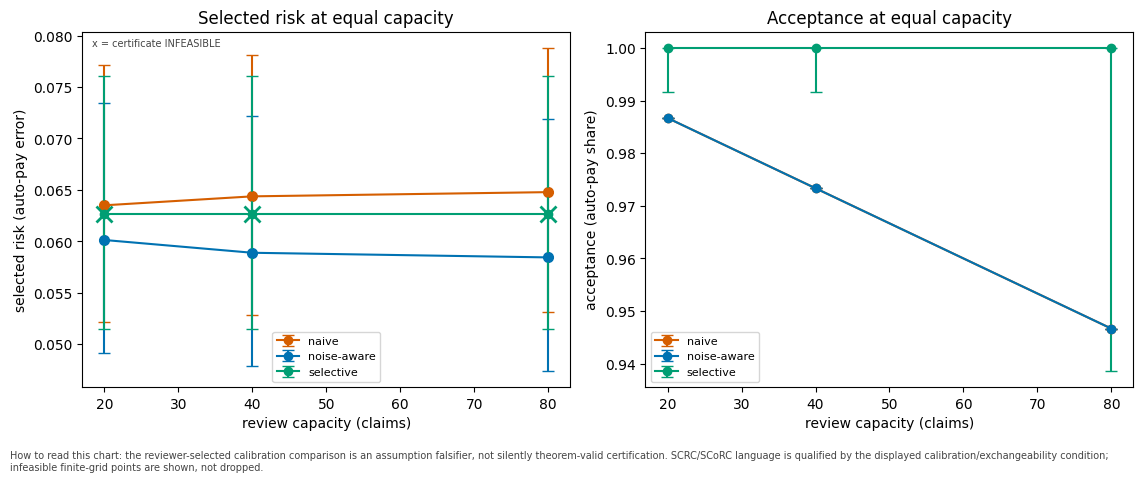

In [10]:
fig = ci.render_capacity(capacity_fig_rows)
plt.show()
plt.close(fig)

**Caption of figure 03.** *"How to read this chart: utility subtracts review
cost; dollars are heavy-tailed (mean and median both reported); no SCoRC benchmark number is quoted and no population guarantee follows from this synthetic fixture."*

**Labels.** The dollar proxy is `derived here`; reviewer-selected calibration is an **assumption falsifier**, not
theorem-valid certification; utility subtracts review cost; the SCoRC paper's benchmark numbers are not quoted.

**How to read this chart (dollar CSV).** The x-axis is reviewer minutes; solid lines with 95% bootstrap intervals are
**dollars recovered**, dashed lines are **net utility after review cost** (recovered minus minutes x $1.50). The
noise-aware (blue) curve is the CCEM ranking, the naive (vermillion) curve is the single-verdict ranking; both are
`derived here` on heavy-tailed synthetic dollars, so a single seed can hit $0 or a very large tail. **The
reviewer-selected calibration comparison is an assumption falsifier, not theorem-valid certification.** no SCoRC benchmark
number is quoted and no population guarantee follows from this fixture.

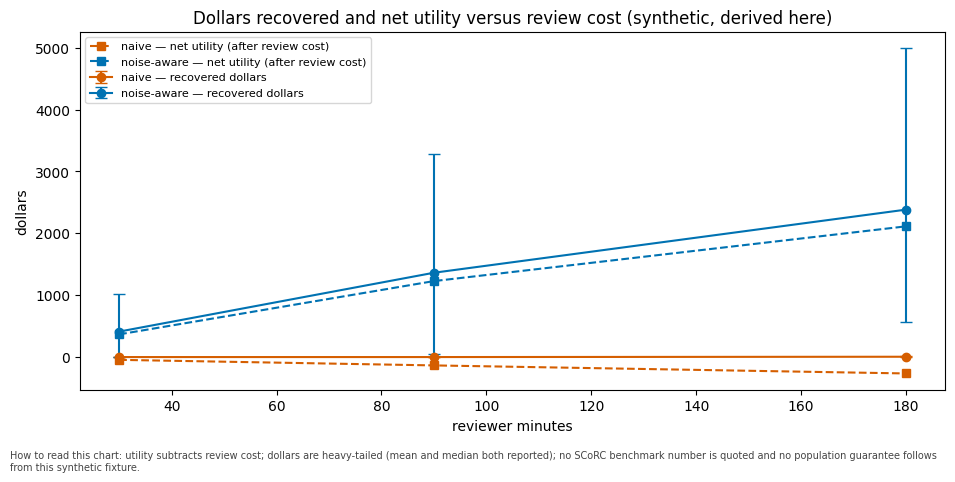

In [11]:
fig = ci.render_dollars(dollars_fig_rows)
plt.show()
plt.close(fig)

**Claim (Assumption 7 / selector status).** Verbatim: *"Constructing g directly from D_cert
('certify-learned' option) is strictly forbidden"*, and from the paper's violation list, *"reviewer feedback or dynamically
constructed routing on the certification set"* violates the selector-status and i.i.d. conditions. That is why the arm
below is a **falsifier**, not a certification: it deliberately calibrates on reviewer-selected claims.

**Claim (what the paper does not promise).** Verbatim: *"The finite-sample coverage and risk
bounds of SCRC-T strictly require sample exchangeability (Theorem 2)"* and *"SCRC-I strictly require i.i.d. sampling
(Proposition 4)"*. The falsifier study runs the **identical** SCRC-I code on three calibration samplings (randomized
audit / scorer-selected high-risk / scorer-selected low-risk) and evaluates each on fresh streams with latent truth, so
only the selection mechanism changes.

**Labels.** This chart is an **assumption falsifier, not theorem-valid certification**; the utility/loss instruments are
`derived here`; the SCoRC paper's benchmark numbers are not quoted.

In [12]:
# Stage 4c - run the calibration-sampling falsifier (4 seeds) and check it before plotting
t_falsifier = time.perf_counter()
falsifier = ci.calibration_falsifier_study(seeds=(11, 23, 37, 53))
falsifier_seconds = time.perf_counter() - t_falsifier
falsifier_rows = falsifier["rows"]
arms_order = ("randomized_audit", "selected_high_risk", "selected_low_risk")
assert len(falsifier_rows) == 4 and falsifier["n_seeds"] == 4
for row in falsifier_rows:
    assert set(row["arms"]) == set(arms_order)
    for arm in arms_order:
        entry = row["arms"][arm]
        assert np.isfinite(entry["calibration_risk_observed"]) and np.isfinite(entry["test_risk"])
        assert entry["test_risk_low"] <= entry["test_risk"] <= entry["test_risk_high"]
        assert abs(sum(entry["selected_share_by_class"]) - 1.0) < 1e-9
print(f"check 25: falsifier rows complete: 4 seeds x 3 arms, calibration risk / test risk finite, class shares sum to 1 (took {falsifier_seconds:.1f}s)")

for key in ("diff_high_vs_audit", "diff_low_vs_audit"):
    mean = falsifier[key]["mean"]
    low, high = falsifier[key]["interval"]
    assert np.isfinite(mean) and np.isfinite(low) and np.isfinite(high) and low <= mean <= high
print("check 26: paired calibration-risk differences are finite with ordered intervals:",
      f"high-vs-audit {falsifier['diff_high_vs_audit']['mean']:+.4f} [{falsifier['diff_high_vs_audit']['interval'][0]:+.4f}, {falsifier['diff_high_vs_audit']['interval'][1]:+.4f}]",
      f"| low-vs-audit {falsifier['diff_low_vs_audit']['mean']:+.4f} [{falsifier['diff_low_vs_audit']['interval'][0]:+.4f}, {falsifier['diff_low_vs_audit']['interval'][1]:+.4f}]")

arm_cal = {arm: {"k": 0, "n": 0} for arm in arms_order}
for row in falsifier_rows:
    for arm in arms_order:
        entry = row["arms"][arm]
        arm_cal[arm]["k"] += int(round(entry["calibration_risk_observed"] * entry["calibration_size"]))
        arm_cal[arm]["n"] += int(entry["calibration_size"])
for arm in arms_order:
    assert arm_cal[arm]["n"] > 0
print("check 27: pooled calibration sizes per arm:", ", ".join(f"{arm}={arm_cal[arm]['n']}" for arm in arms_order))

check 25: falsifier rows complete: 4 seeds x 3 arms, calibration risk / test risk finite, class shares sum to 1 (took 1.9s)
check 26: paired calibration-risk differences are finite with ordered intervals: high-vs-audit +0.0459 [+0.0322, +0.0595] | low-vs-audit -0.0152 [-0.0381, +0.0076]
check 27: pooled calibration sizes per arm: randomized_audit=1523, selected_high_risk=1523, selected_low_risk=1523


**How to read this chart (calibration falsifier).** Three calibration arms on the x-axis: randomized audit (exchangeable control),
scorer-selected high risk (the scorer's riskiest claims), and scorer-selected low risk (the scorer's
most-confident-clean claims). Filled circles with **Wilson 95% intervals** are each arm's pooled **calibration risk
observed**; squares on a dashed line are the **mean test risk on fresh truth** (seeds 11/23/37/53), and the dotted line is
the alpha = 0.05 target. Read the gap between a selected arm's calibration reading and the audit control as the
**assumption break the falsifier measures**, not as a theorem failure: **reviewer-selected calibration is an assumption
falsifier, not theorem-valid certification**. The loss here is latent truth so the comparison isolates selection, and the
utility instrument subtracts review cost elsewhere in the notebook; no SCoRC benchmark number is quoted.

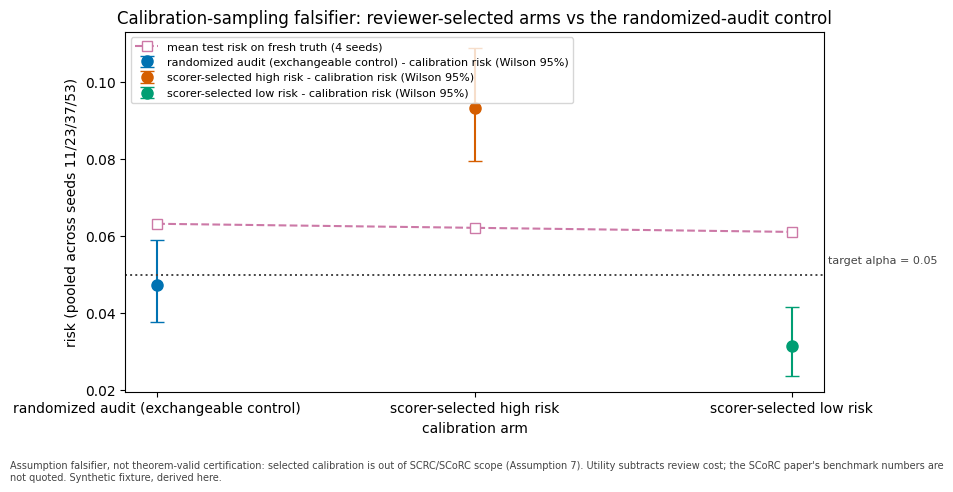

In [13]:
x = np.arange(len(arms_order))
cal_mean, cal_low, cal_high, test_mean = [], [], [], []
for arm in arms_order:
    low, high = ci.wilson_interval(arm_cal[arm]["k"], arm_cal[arm]["n"])
    cal_mean.append(arm_cal[arm]["k"] / arm_cal[arm]["n"])
    cal_low.append(low)
    cal_high.append(high)
    test_mean.append(float(np.mean([row["arms"][arm]["test_risk"] for row in falsifier_rows])))
cal_mean = np.array(cal_mean)
cal_low = np.array(cal_low)
cal_high = np.array(cal_high)
test_mean = np.array(test_mean)

fig, ax = plt.subplots(figsize=(9.6, 4.9))
colors = {"randomized_audit": PALETTE["blue"], "selected_high_risk": PALETTE["vermillion"], "selected_low_risk": PALETTE["green"]}
for i, arm in enumerate(arms_order):
    ax.errorbar(x[i], cal_mean[i], yerr=[[cal_mean[i] - cal_low[i]], [cal_high[i] - cal_mean[i]]],
                fmt="o", capsize=5, markersize=8, color=colors[arm],
                label=f"{CHART_ARM_LABELS[arm]} - calibration risk (Wilson 95%)")
ax.plot(x, test_mean, "s--", color=PALETTE["purple"], markerfacecolor="white", markersize=7,
        label="mean test risk on fresh truth (4 seeds)")
ax.axhline(float(ci.CONFIG["alpha"]), color="#444444", linestyle=":", linewidth=1.4)
ax.text(2.46, float(ci.CONFIG["alpha"]) + 0.0025, f"target alpha = {float(ci.CONFIG['alpha']):.2f}", fontsize=8,
        color="#444444", ha="right", va="bottom")
ax.set_xticks(x, [CHART_ARM_LABELS[arm] for arm in arms_order])
ax.set(xlabel="calibration arm", ylabel="risk (pooled across seeds 11/23/37/53)",
       title="Calibration-sampling falsifier: reviewer-selected arms vs the randomized-audit control")
ax.legend(fontsize=8, loc="upper left")
fig.text(0.01, 0.005,
         "Assumption falsifier, not theorem-valid certification: selected calibration is out of SCRC/SCoRC scope (Assumption 7). "
         "Utility subtracts review cost; the SCoRC paper's benchmark numbers are not quoted. Synthetic fixture, derived here.",
         ha="left", va="bottom", fontsize=7, color="#444444", wrap=True)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()
plt.close(fig)

### How to read this chart (per-seed spread, not just the pooled point)

The chart above pools all 4 seeds into one Wilson interval per arm; this one shows the 4 underlying
`calibration_risk_observed` values themselves; one point per seed, jittered, with a box marking the
median and interquartile range. With n=4 per arm a smooth density would be misleading, so raw points
are shown instead of a violin. The dotted line is the same alpha = 0.05 target. A pooled interval can
look tight even when individual seeds disagree; the point of this second view is to make that spread
checkable by eye, seed by seed, arm by arm - the same cross-seed honesty this project applies everywhere
else (the identifiability forest plot in NB2, the paired seed comparison, the ledger).

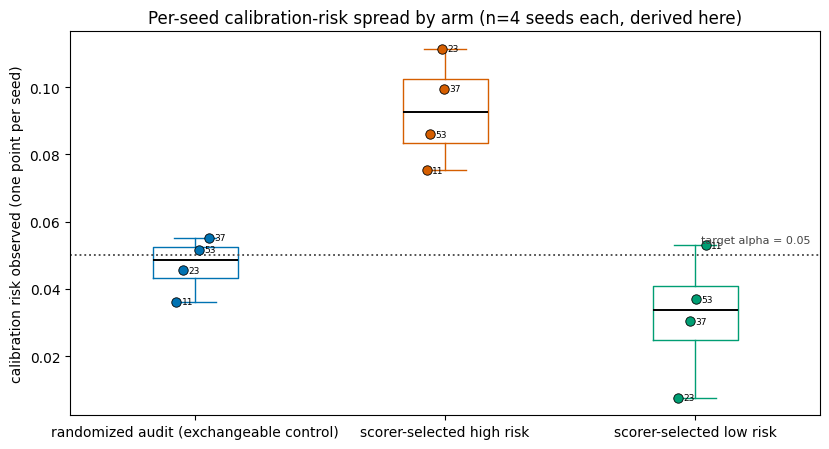

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
rng_jitter = np.random.default_rng(3)
for i, arm in enumerate(arms_order):
    seed_risks = [row["arms"][arm]["calibration_risk_observed"] for row in falsifier_rows]
    seed_ids = [row["seed"] for row in falsifier_rows]
    ax.boxplot([seed_risks], positions=[i], widths=0.34, showfliers=False,
               boxprops={"color": colors[arm]}, whiskerprops={"color": colors[arm]},
               capprops={"color": colors[arm]}, medianprops={"color": "black", "linewidth": 1.4})
    jitter = rng_jitter.uniform(-0.09, 0.09, size=len(seed_risks))
    ax.scatter(np.full(len(seed_risks), i) + jitter, seed_risks, color=colors[arm], s=46,
               edgecolor="black", linewidth=0.6, zorder=3)
    for x_pos, y_val, seed_id in zip(np.full(len(seed_risks), i) + jitter, seed_risks, seed_ids):
        ax.annotate(str(seed_id), (x_pos, y_val), fontsize=6.5, xytext=(4, 0),
                    textcoords="offset points", va="center")
ax.axhline(float(ci.CONFIG["alpha"]), color="#444444", linestyle=":", linewidth=1.3)
ax.text(len(arms_order) - 0.54, float(ci.CONFIG["alpha"]) + 0.003, f"target alpha = {float(ci.CONFIG['alpha']):.2f}",
        fontsize=8, color="#444444", ha="right", va="bottom")
ax.set_xticks(range(len(arms_order)), [CHART_ARM_LABELS[arm] for arm in arms_order])
ax.set_ylabel("calibration risk observed (one point per seed)")
ax.set_title("Per-seed calibration-risk spread by arm (n=4 seeds each, derived here)")
fig.tight_layout()
plt.show()

## Stage 5 - Metric observability

**Claim (derived here).** The observability instruments are the project's own: a per-run ledger (seed, config hash,
capacity, measured runtime), pre-declared monitors with a hypothesis and a trigger scenario, and the falsifier tables
that report what the calibration arms actually saw. The monitors' hypotheses and trigger rules are fixed **before** the
simulation runs (`derived here`); their measured false-alarm and miss rates are reported as-is, including a scenario that
never triggers.

**Claim (rejected-case limits, quoted verbatim).** *"A limitation of the current framework is that
it does not provide a second-stage prediction-set guarantee for rejected samples; these cases are intentionally deferred
and should be handled by a downstream fallback mechanism such as human review or a more specialized model."* So the
routed-to-review branch is reported for **burden**, never for safety.

In [15]:
# Stage 5 - falsifier observability tables
falsifier_table = []
for row in falsifier_rows:
    for arm in arms_order:
        entry = row["arms"][arm]
        shares = entry["selected_share_by_class"]
        falsifier_table.append([
            CHART_ARM_LABELS[arm].replace(" (exchangeable control)", ""),
            row["seed"],
            entry["calibration_size"],
            f4(entry["calibration_risk_observed"]),
            "/".join(f"{s:.2f}" for s in shares),
            f4(entry["ambiguous_share"]),
            f4(entry["threshold"]),
            f4(entry["test_risk"]) + f" [{f4(entry['test_risk_low'])}, {f4(entry['test_risk_high'])}]",
            f4(entry["test_acceptance"]),
            "exceeds" if entry["exceeds_target"] else "within",
        ])
show("**Falsifier table (per arm, per seed): calibration risk observed, selected share by class (compliant/billing_error/medically_unnecessary), ambiguous share, threshold, test risk with Wilson interval, test acceptance, exceeds the alpha = 0.05 target.**\n\n"
     + pipe_table(["arm", "seed", "cal size", "calibration risk", "share by class", "ambiguous share", "threshold",
                   "test risk [low, high]", "test acceptance", "vs target"], falsifier_table))

exceed_table = []
for arm in arms_order:
    rate = falsifier[f"{arm}_exceedance_rate"]
    low, high = falsifier[f"{arm}_exceedance_interval"]
    assert 0.0 <= rate <= 1.0 and low <= rate <= high
    exceed_table.append([CHART_ARM_LABELS[arm], f4(falsifier[f"{arm}_risk_mean"]), f4(rate), f"[{f4(low)}, {f4(high)}]"])
show("**Across-seed exceedance of the alpha = 0.05 target (test risk on fresh truth), with Wilson 95% intervals.**\n\n"
     + pipe_table(["arm", "mean test risk", "exceedance rate", "Wilson 95% interval"], exceed_table))

diff_table = []
for key, label in (("diff_high_vs_audit", "selected high-risk minus randomized audit"),
                   ("diff_low_vs_audit", "selected low-risk minus randomized audit")):
    mean = falsifier[key]["mean"]
    low, high = falsifier[key]["interval"]
    assert np.isfinite(mean) and np.isfinite(low) and np.isfinite(high) and low <= mean <= high
    diff_table.append([label, f"{mean:+.4f}", f"[{low:+.4f}, {high:+.4f}]", "yes" if (low > 0 or high < 0) else "no"])
show("**Paired calibration-risk differences (selected arm minus randomized audit, per seed; 95% bootstrap interval).**\n\n"
     + pipe_table(["comparison", "mean difference", "95% interval", "interval excludes 0"], diff_table))
print("check 28: falsifier differences finite with ordered intervals; exceedance rates and intervals valid (all asserted above)")

**Falsifier table (per arm, per seed): calibration risk observed, selected share by class (compliant/billing_error/medically_unnecessary), ambiguous share, threshold, test risk with Wilson interval, test acceptance, exceeds the alpha = 0.05 target.**

| arm | seed | cal size | calibration risk | share by class | ambiguous share | threshold | test risk [low, high] | test acceptance | vs target |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| randomized audit | 11 | 359 | 0.0362 | 0.96/0.03/0.01 | 0.0641 | 0.0000 | 0.0627 [0.0515, 0.0761] | 1.0000 | exceeds |
| scorer-selected high risk | 11 | 359 | 0.0752 | 0.92/0.05/0.03 | 0.1755 | 0.7000 | 0.0586 [0.0477, 0.0719] | 0.9667 | exceeds |
| scorer-selected low risk | 11 | 359 | 0.0529 | 0.95/0.04/0.01 | 0.0306 | 0.8800 | 0.0453 [0.0255, 0.0792] | 0.1620 | within |
| randomized audit | 23 | 395 | 0.0456 | 0.95/0.03/0.02 | 0.0937 | 0.0000 | 0.0700 [0.0582, 0.0840] | 1.0000 | exceeds |
| scorer-selected high risk | 23 | 395 | 0.1114 | 0.89/0.07/0.04 | 0.2152 | nan | 0.0700 [0.0582, 0.0840] | 1.0000 | exceeds |
| scorer-selected low risk | 23 | 395 | 0.0076 | 0.99/0.01/0.00 | 0.0152 | 0.0000 | 0.0700 [0.0582, 0.0840] | 1.0000 | exceeds |
| randomized audit | 37 | 362 | 0.0552 | 0.94/0.04/0.02 | 0.0746 | 0.7000 | 0.0516 [0.0410, 0.0648] | 0.8920 | exceeds |
| scorer-selected high risk | 37 | 362 | 0.0994 | 0.90/0.08/0.02 | 0.1796 | 0.7000 | 0.0516 [0.0410, 0.0648] | 0.8920 | exceeds |
| scorer-selected low risk | 37 | 362 | 0.0304 | 0.97/0.01/0.02 | 0.0276 | 0.0000 | 0.0607 [0.0497, 0.0739] | 1.0000 | exceeds |
| randomized audit | 53 | 407 | 0.0516 | 0.95/0.03/0.02 | 0.0688 | 0.6900 | 0.0688 [0.0566, 0.0835] | 0.9107 | exceeds |
| scorer-selected high risk | 53 | 407 | 0.0860 | 0.91/0.04/0.04 | 0.1425 | nan | 0.0687 [0.0569, 0.0826] | 1.0000 | exceeds |
| scorer-selected low risk | 53 | 407 | 0.0369 | 0.96/0.03/0.01 | 0.0467 | 0.0000 | 0.0687 [0.0569, 0.0826] | 1.0000 | exceeds |

**Across-seed exceedance of the alpha = 0.05 target (test risk on fresh truth), with Wilson 95% intervals.**

| arm | mean test risk | exceedance rate | Wilson 95% interval |
| --- | --- | --- | --- |
| randomized audit (exchangeable control) | 0.0633 | 1.0000 | [0.5101, 1.0000] |
| scorer-selected high risk | 0.0622 | 1.0000 | [0.5101, 1.0000] |
| scorer-selected low risk | 0.0612 | 0.7500 | [0.3006, 0.9544] |

**Paired calibration-risk differences (selected arm minus randomized audit, per seed; 95% bootstrap interval).**

| comparison | mean difference | 95% interval | interval excludes 0 |
| --- | --- | --- | --- |
| selected high-risk minus randomized audit | +0.0459 | [+0.0322, +0.0595] | yes |
| selected low-risk minus randomized audit | -0.0152 | [-0.0381, +0.0076] | no |

check 28: falsifier differences finite with ordered intervals; exceedance rates and intervals valid (all asserted above)


In [16]:
# Stage 5 - monitor operating characteristics and the run ledger
monitors = [ci.agreement_drift_monitor(), ci.queue_volume_monitor()]
monitor_table = []
for monitor in monitors:
    fa_low, fa_high = monitor["false_alarm_interval"]
    miss_low, miss_high = monitor["miss_interval"]
    assert 0.0 <= monitor["false_alarm_rate"] <= 1.0 and 0.0 <= monitor["miss_rate"] <= 1.0
    monitor_table.append([
        monitor["monitor"],
        monitor["hypothesis"],
        monitor["trigger_scenario"],
        f4(monitor["false_alarm_rate"]) + f" [{f4(fa_low)}, {f4(fa_high)}]",
        f4(monitor["miss_rate"]) + f" [{f4(miss_low)}, {f4(miss_high)}]",
    ])
show("**Pre-declared monitors: hypothesis, trigger scenario, and measured false-alarm / miss rates (300 replicates each; Wilson 95% intervals).**\n\n"
     + pipe_table(["monitor", "H0 (hypothesis)", "trigger scenario", "false-alarm rate", "miss rate"], monitor_table))

ledger_dir = Path(tempfile.gettempdir()) / "claims-payment-integrity-labels"
ledger_dir.mkdir(parents=True, exist_ok=True)
ledger_path = ledger_dir / "claims_integrity_03_run_ledger.jsonl"
ci.write_ledger(ledger_path, ledger_records)
assert ledger_path.exists() and ledger_path.read_text().count("\n") == len(ledger_records)
print(f"check 29: run ledger written ({len(ledger_records)} rows, one per (seed, capacity))")
print("check 30: monitors executed with pre-declared hypotheses (no hypothesis was changed after seeing the rates); both rates and intervals are in [0, 1]")
print("check 31: ledger identity: every record carries the frozen config hash", config_hash[:16], "...")

**Pre-declared monitors: hypothesis, trigger scenario, and measured false-alarm / miss rates (300 replicates each; Wilson 95% intervals).**

| monitor | H0 (hypothesis) | trigger scenario | false-alarm rate | miss rate |
| --- | --- | --- | --- | --- |
| reviewer_agreement_drift | windowed mean agreement >= 0.6 | agreement drops to 0.5 over a 10-observation window | 0.0000 [0.0000, 0.0126] | 0.0000 [0.0000, 0.0126] |
| queue_volume_overload | windowed mean volume <= 110.0 | volume rises to 1.60x capacity over a 8-observation window | 0.0067 [0.0018, 0.0240] | 0.0000 [0.0000, 0.0126] |

check 29: run ledger written (6 rows, one per (seed, capacity))
check 30: monitors executed with pre-declared hypotheses (no hypothesis was changed after seeing the rates); both rates and intervals are in [0, 1]
check 31: ledger identity: every record carries the frozen config hash 0066ca74e7e74185 ...


The capacity and dollar means used above are the same `capacity_table` / `dollars_table` computed in
Stage 3c; they are not repeated here verbatim. Two new views follow: the monitors' operating characteristics as
a chart (NB2 computes the same two monitors as text only; here the same monitor rules run on this notebook's
capacity grid and are charted), and a marginal-return chart.

### How to read this chart (monitor operating characteristics)

For each monitor, the blue bar is the measured **false-alarm rate** under H0 (the rule fires when nothing is
wrong) and the orange bar is the measured **miss rate** under the stated H1 trigger scenario (the rule stays
silent when it should fire), both with **95% Wilson intervals** over 300 replicates. This is the same pair NB2
measures on its own two monitor calls; charting it here confirms the pre-declared rules behave the same way on
NB3's reused stream and capacity grid. A wide interval or a nonzero miss rate is a reason to raise the replicate
count or revisit the threshold before trusting the monitor operationally - neither is a paper claim.

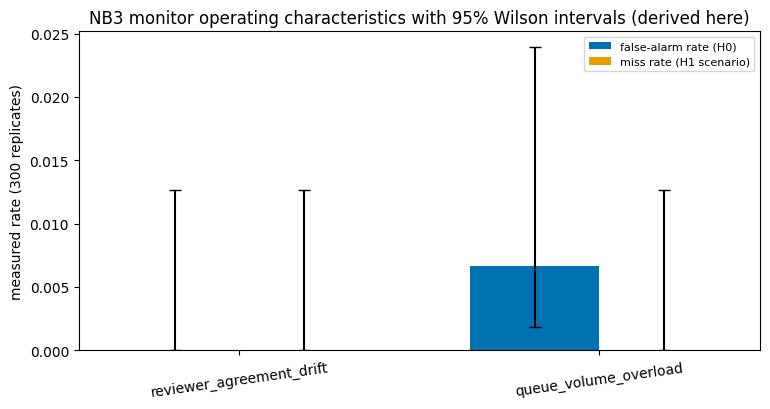

In [17]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
monitor_names = [m["monitor"] for m in monitors]
positions = np.arange(len(monitors))
width = 0.36
false_alarm = np.array([m["false_alarm_rate"] for m in monitors])
miss = np.array([m["miss_rate"] for m in monitors])
false_alarm_err = np.array([
    [m["false_alarm_rate"] - m["false_alarm_interval"][0] for m in monitors],
    [m["false_alarm_interval"][1] - m["false_alarm_rate"] for m in monitors],
])
miss_err = np.array([
    [m["miss_rate"] - m["miss_interval"][0] for m in monitors],
    [m["miss_interval"][1] - m["miss_rate"] for m in monitors],
])
ax.bar(positions - width / 2, false_alarm, width=width, yerr=false_alarm_err, capsize=4,
       color=PALETTE["blue"], label="false-alarm rate (H0)")
ax.bar(positions + width / 2, miss, width=width, yerr=miss_err, capsize=4,
       color=PALETTE["orange"], label="miss rate (H1 scenario)")
ax.set_xticks(positions, monitor_names, rotation=8)
ax.set_ylabel("measured rate (300 replicates)")
ax.set_title("NB3 monitor operating characteristics with 95% Wilson intervals (derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### How to read this chart (diminishing marginal return)

Dollars recovered per reviewer-minute, by policy, across the same three minute budgets as the Stage 3c dollar
table (30/90/180 minutes; means over seeds 11 and 23). Both lines fall as the budget grows: the richest,
easiest-to-catch claims are reviewed first, so each additional minute recovers less than the one before it -
the textbook shape of diminishing returns on a heavy-tailed queue. The noise-aware line sits above naive at
every budget, so the ranking's advantage from the Stage 3 precision@K comparison survives into the dollar
proxy, but the gap narrows as the budget grows and more of the tail gets reviewed either way. This is a
`derived here` synthetic proxy, not a claim about real recoverable dollars.

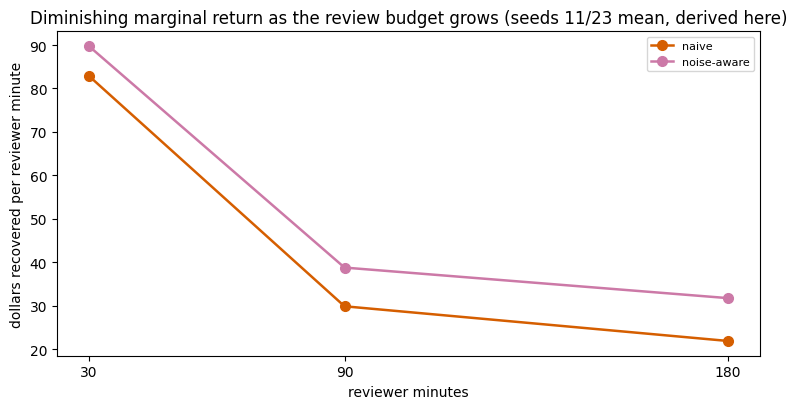

In [18]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
minutes_grid = (30, 90, 180)
for policy, color in (("naive", PALETTE["vermillion"]), ("noise-aware", PALETTE["purple"])):
    per_minute = []
    for minutes in minutes_grid:
        group = by_min_policy[(policy, minutes)]
        recovered = float(np.mean([g["dollars_recovered"] for g in group]))
        per_minute.append(recovered / minutes)
    ax.plot(minutes_grid, per_minute, "o-", color=color, linewidth=1.8, markersize=7, label=policy)
ax.set_xticks(minutes_grid)
ax.set_xlabel("reviewer minutes")
ax.set_ylabel("dollars recovered per reviewer minute")
ax.set_title("Diminishing marginal return as the review budget grows (seeds 11/23 mean, derived here)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Closing - cost accounting and what stays open

**Cost accounting (all `derived here`, synthetic; the dollar proxy is heavy-tailed, so single-seed numbers can be extreme).**
Reviewer time is `capacity x 3.0 min/review`; review cost is `minutes x $1.50/min` (config `cost_per_minute`), and net
utility subtracts exactly that cost. On the committed dollar CSV (identical to the study this notebook runs, means
over seeds 11 and 23):

| policy | reviewer minutes | claims reviewed | review cost | dollars recovered | net utility |
| --- | --- | --- | --- | --- | --- |
| naive | 30 | 10 | $45.00 | $2,487.07 | $2,442.07 |
| naive | 90 | 30 | $135.00 | $2,687.27 | $2,552.27 |
| naive | 180 | 60 | $270.00 | $3,937.05 | $3,667.05 |
| noise-aware | 30 | 10 | $45.00 | $2,692.86 | $2,647.86 |
| noise-aware | 90 | 30 | $135.00 | $3,489.40 | $3,354.40 |
| noise-aware | 180 | 60 | $270.00 | $5,712.45 | $5,442.45 |

The noise-aware ranking is weakly better at every budget, but the proxy is so heavy-tailed that seed 11's naive top-K
recovered $0.00 - so this is a direction, not a precise ROI. The **capacity** grid (20/40/80 claims = 60/120/240 minutes)
is separate from the dollar grid (30/90/180 minutes = 10/30/60 claims); both are reported above.

**What this notebook measured.** (1) The strict alpha = 0.05 target is below the ~6% passive base rate and the
finite-sample certificate refuses at every candidate; the configured looser target alpha = 0.10 also refuses, and the
first certified point in the probe bracket appears at alpha = 0.11 (derived here). (2) The randomized-audit SCRC-I arm -
exchangeable by construction - likewise cannot certify 0.05, because its verdict-based loss rate is ~27% (auditors
over-call) and the counting-quantile budget is too small at n = 359; the monitor's permissiveness at this sample size is
reported, not hidden. (3) In the falsifier, the audit control and the low-risk arm are permissive at this sample size
(exceedance rates 1.00 and 0.75 of 4 seeds against alpha = 0.05), the selected arms change what calibration sees
(high-risk calibration risk +0.046 over audit, interval excludes zero; low-risk -0.015, unresolved), and that is the
**measured assumption break, not a theorem failure**. (4) Noise-aware ranking beats naive accepted risk at every capacity
and seed, but by only ~0.4-0.7 pp because K <= 80 of 1500 claims leaves 95-99% of claims on auto-pay.

**What remains open.** (a) Provider burden: per-provider review load and false-positive concentration are not
instrumented; only claim-level capacity is. (b) Drift: both monitors are simulations of the pre-declared rules, not live
streams - a real deployment would need a rolling agreement/volume feed and a retraining policy. (c) Rejected-case safety:
per the paper's own limitation, no guarantee is inherited for reviewed/rejected claims; this notebook reports burden
only. (d) The certificate's utility uses a conservative $45.00/review cost bound while the capacity/dollar branch uses
$1.50/min x 3.0 min = $4.50/review; the two cost models should be reconciled before any ROI claim. (e) SCoRC's own
benchmark numbers are not quoted, so no SCoRC experiment result appears here. (f) Effect sizes rest on 2 seeds
(capacity/dollars) and 4 seeds (falsifier) of one synthetic scenario.

**Open questions.** (1) Is a certified target in the 11-12% region acceptable for auto-pay, or does the
review budget have to grow (larger n_cert, tighter delta) to certify 5%? (2) Would a larger audit arm give the
verdict-based SCRC control power, or should the control's loss use latent truth for a cleaner separation?
(3) Provider-level burden and rejected-case instrumentation are not yet in place.